# Adzuna jobs — EDA and data-quality report

**Pipeline:** `adzuna-etl` — Adzuna API → raw CSV → clean CSV → validation.

This notebook explores the *cleaned* layer (`data/processed/adzuna_jobs_master.csv`,
plus the aggregate history master) and documents data-quality decisions that
feed the future data-warehouse phase (incremental daily snapshots, SCD Type 2
dimensions: company, location, category; facts: job-ad snapshots by `ingest_date`).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
pd.set_option("display.max_columns", 35)
pd.set_option("display.width", 160)

MASTER = Path("../data/processed/adzuna_jobs_master.csv").resolve()
HISTORY = Path("../data/processed/adzuna_history_master.csv").resolve()

df = pd.read_csv(
    MASTER,
    parse_dates=["created_at", "ingested_at"],
    dtype={"salary_is_predicted": bool},
)
hist = pd.read_csv(HISTORY, parse_dates=["day"])
print(f"jobs snapshot rows : {len(df):,}")
print(f"history rows       : {len(hist):,}")
print(f"ingest partition(s): {sorted(df['ingest_date'].unique())}")
df.head(3)

jobs snapshot rows : 5,000
history rows       : 490
ingest partition(s): ['2026-09-03']


,job_id,adref,title,description,company_name,salary_min,salary_max,salary_currency,salary_is_predicted,location_display_name,location_area_0,location_area_1,location_area_2,latitude,longitude,category_tag,category_label,contract_type,contract_time,created_at,redirect_url,source,country,ingested_at,ingest_date
0,1100269,adzuna-adref-1100269,Accountant,Join our growing team in London. Salary depend...,Capital & County,40000.0,53739.0,GBP,True,London,UK,Greater London,London,NaN,-0.118,marketing-jobs,Marketing Jobs,full_time,permanent,2026-01-01 18:23:10.377317+00:00,https://www.adzuna.co.uk/land/ad/1100269,adzuna,gb,2026-09-03 18:23:10.377330+00:00,2026-09-03
1,1102744,adzuna-adref-1102744,Warehouse Operative,Join our growing team in Manchester. Salary de...,Blue Harbour Group,80000.0,107816.0,GBP,True,Manchester,UK,North West,Manchester,53.480,-2.242,retail-jobs,Retail Jobs,full_time,contract,2026-01-01 18:23:10.377317+00:00,https://www.adzuna.co.uk/land/ad/1102744,adzuna,gb,2026-09-03 18:23:10.377330+00:00,2026-09-03
2,1103812,adzuna-adref-1103812,Delivery Driver,Join our growing team in Birmingham. Salary de...,Meadowsoft,60000.0,71702.0,GBP,True,Birmingham,UK,West Midlands,Birmingham,52.486,-1.890,marketing-jobs,Marketing Jobs,full_time,contract,2026-01-01 18:23:10.377317+00:00,https://www.adzuna.co.uk/land/ad/1103812,adzuna,gb,2026-09-03 18:23:10.377330+00:00,2026-09-03


rows with >1 snapshot (normal for repeated daily runs): 0


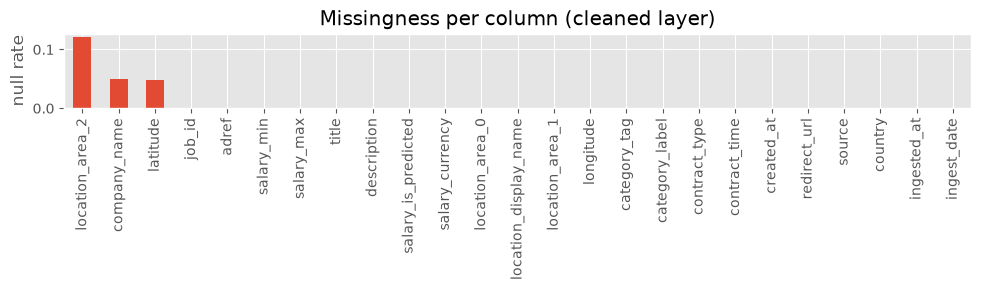

In [2]:
# Snapshot key sanity: the same job_id can appear on multiple ingest dates
key = df.groupby(["job_id", "country"]).size().reset_index(name="snapshots")
print("rows with >1 snapshot (normal for repeated daily runs):", (key["snapshots"] > 1).sum())

missing = df.isna().mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 3))
missing.plot.bar(ax=ax)
ax.set_ylabel("null rate")
ax.set_title("Missingness per column (cleaned layer)")
plt.tight_layout()

In [3]:
# Categorical distributions
for col in ["category_label", "contract_time", "contract_type"]:
    if col in df:
        vc = df[col].value_counts(dropna=False).head(12)
        print(f"--- {col} ({len(vc)} unique) ---")
        print(vc.to_string(), "\n")

print("--- top 15 companies ---")
print(df["company_name"].value_counts(dropna=False).head(15).to_string())
print("\n--- top 15 locations ---")
print(df["location_display_name"].value_counts(dropna=False).head(15).to_string())

--- category_label (10 unique) ---
category_label
IT Jobs                       516
Teaching Jobs                 513
Logistics & Warehouse Jobs    507
HR Jobs                       505
Engineering Jobs              498
Marketing Jobs                497
Sales Jobs                    497
Healthcare & Nursing Jobs     496
Retail Jobs                   488
Accounting & Finance Jobs     483 

--- contract_time (2 unique) ---
contract_time
contract     2547
permanent    2453 

--- contract_type (2 unique) ---
contract_type
full_time    2689
part_time    2311 

--- top 15 companies ---
company_name
Vertex Engineering          428
Capital & County            417
Acme Analytics Ltd          414
DataWise Solutions          407
Quantum Labs                404
Sterling Retail Partners    396
Juniper Health              395
Meadowsoft                  395
Skyline Logistics           389
Northern Star Consulting    376
Bright Path Tech            366
Blue Harbour Group          364
NaN             

salary_min  describe:
count      5000.0
mean      50773.0
std       25949.0
min       20000.0
25%       30000.0
50%       40000.0
75%       60882.0
max      139328.0

salary_max  describe:
count      5000.0
mean      69642.0
std       27510.0
min       22077.0
25%       48958.0
50%       63970.0
75%       87140.0
max      139914.0

inverted pairs (min>max): 0
salary_is_predicted true: 4376


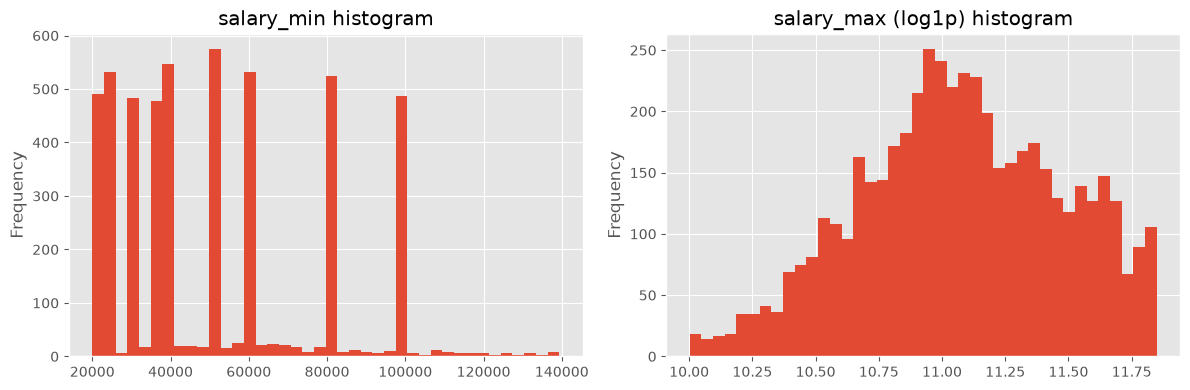

In [4]:
# Salary field health
sal = df[["salary_min", "salary_max"]].dropna()
print("salary_min  describe:")
print(sal["salary_min"].describe().round(0).to_string())
print("\nsalary_max  describe:")
print(sal["salary_max"].describe().round(0).to_string())
print("\ninverted pairs (min>max):", (sal["salary_min"] > sal["salary_max"]).sum())
print("salary_is_predicted true:", int(df["salary_is_predicted"].sum()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if not sal.empty:
    sal["salary_min"].plot.hist(ax=axes[0], bins=40)
    axes[0].set_title("salary_min histogram")
    np.log1p(sal["salary_max"]).plot.hist(ax=axes[1], bins=40)
    axes[1].set_title("salary_max (log1p) histogram")
plt.tight_layout()

first created: 2026-01-01 18:23:10.377317+00:00 | last created: 2026-09-02 18:23:10.377317+00:00


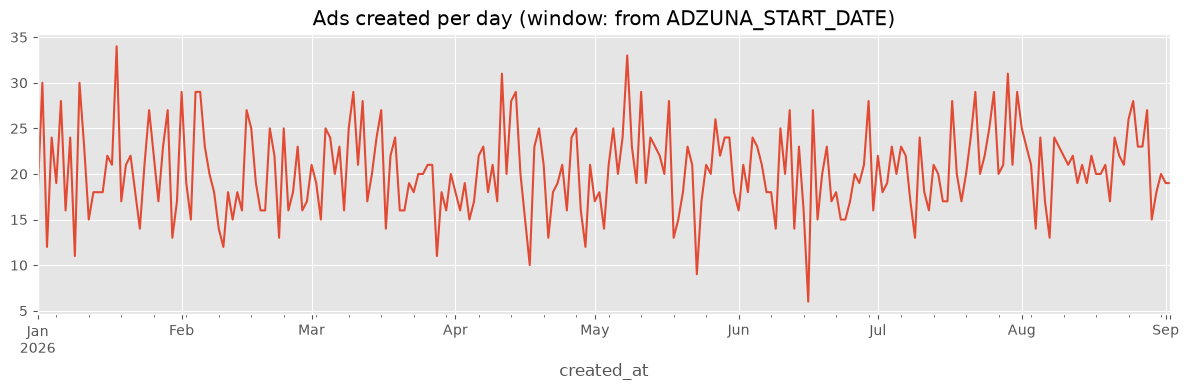

In [5]:
# Ad creation timeline (i.e. jobs posted since the start of the window)
created = df["created_at"].dropna()
if not created.empty:
    timeline = created.dt.floor("D").value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(12, 4))
    timeline.plot(ax=ax)
    ax.set_title("Ads created per day (window: from ADZUNA_START_DATE)")
    plt.tight_layout()
    print("first created:", created.min(), "| last created:", created.max())

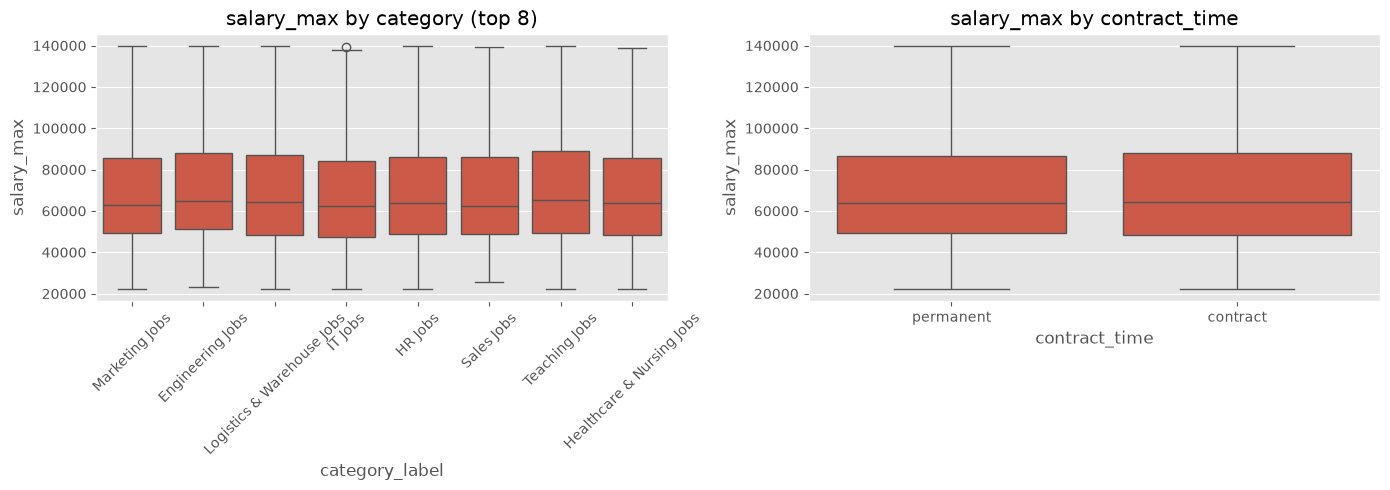

In [6]:
# Salary vs category / contract (boxplots)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if "salary_max" in df and df["salary_max"].notna().any():
    top_cats = df["category_label"].value_counts().head(8).index
    sub = df[df["category_label"].isin(top_cats) & df["salary_max"].notna()]
    sns.boxplot(data=sub, x="category_label", y="salary_max", ax=axes[0])
    axes[0].tick_params(axis="x", rotation=45)
    axes[0].set_title("salary_max by category (top 8)")
    sns.boxplot(data=df[df["salary_max"].notna()], x="contract_time", y="salary_max", ax=axes[1])
    axes[1].set_title("salary_max by contract_time")
plt.tight_layout()

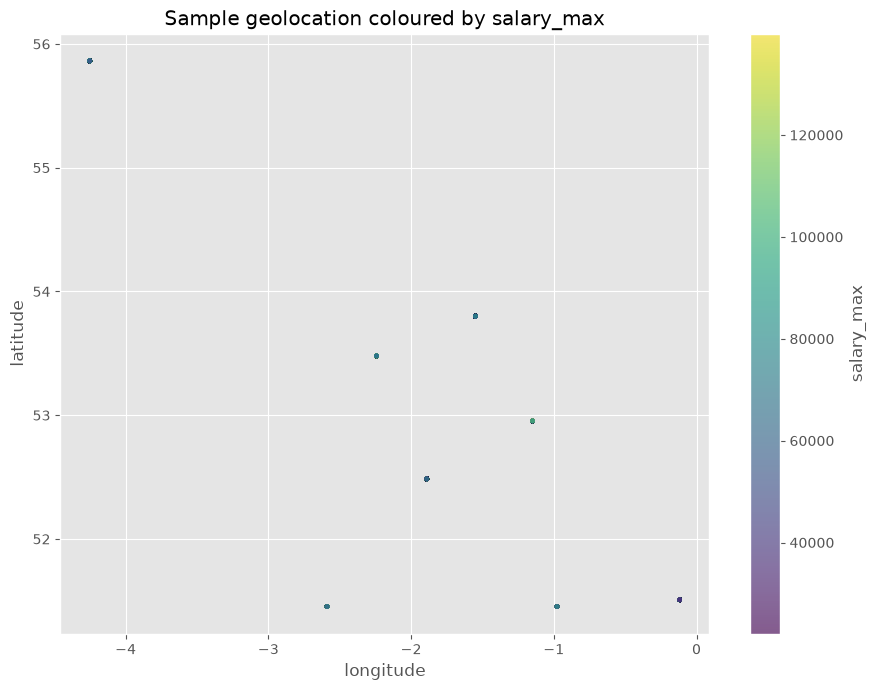

In [7]:
# Locations on a scatter (lat/lon) + salary colouring
geo = df[df["latitude"].notna() & df["longitude"].notna() & df["salary_max"].notna()]
if len(geo):
    fig, ax = plt.subplots(figsize=(9, 7))
    sc = ax.scatter(geo["longitude"], geo["latitude"], c=geo["salary_max"],
                    cmap="viridis", s=8, alpha=0.6)
    ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
    ax.set_title("Sample geolocation coloured by salary_max")
    plt.colorbar(sc, label="salary_max")
    plt.tight_layout()

day range: 2026-01-02 00:00:00 -> 2026-09-03 00:00:00


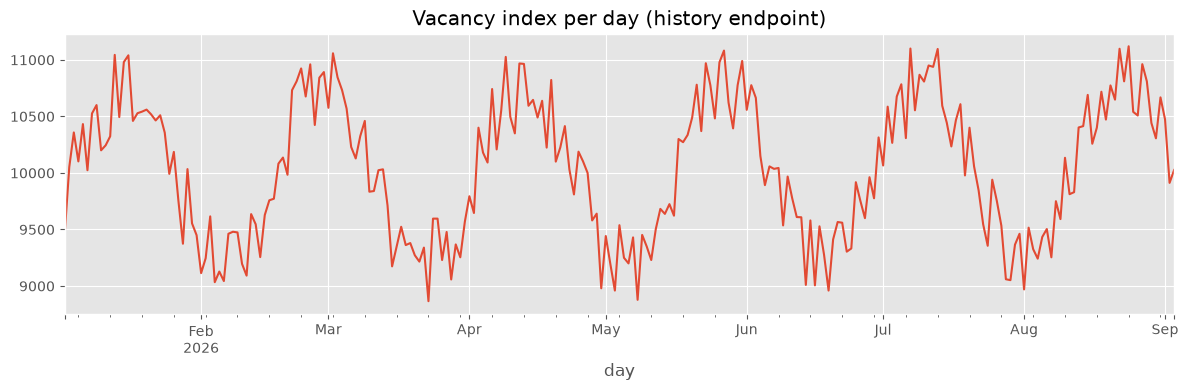

In [8]:
# Aggregate trend from the history endpoint (covers Jan 2026 -> now)
if not hist.empty:
    daily = hist.groupby("day")["count"].sum().sort_index()
    fig, ax = plt.subplots(figsize=(12, 4))
    daily.plot(ax=ax)
    ax.set_title("Vacancy index per day (history endpoint)")
    plt.tight_layout()
    print("day range:", daily.index.min(), "->", daily.index.max())

## Conclusions → warehouse design

- **Snapshot model:** `(job_id, country, ingest_date)` is the natural key of one
  observation — perfect for a fact table of daily snapshots and for SCD Type 2
  on mutable attributes (salary, contract type) using `created_at`/`ingested_at`.
- **Dimensions to build later:** `dim_company` (company_name), `dim_location`
  (lat/lon + area hierarchy), `dim_category` (tag/label), `dim_job` (title),
  `dim_date` (calendar).
- **Incremental loads:** each `processed/jobs/{ingest_date}_{country}_*.csv`
  partition is a complete delta — the future loader can ingest only new partitions.
- **Known limitations:** Adzuna's search API only returns *live* listings (~45
  days), so job-level history before the pipeline starts cannot be backfilled;
  the history endpoint provides daily aggregate trends to fill that gap.

**Next phase (not in this notebook):** load masters/partitions into DuckDB or a
warehouse, build the SCD Type 2 dimensions and snapshot fact, then dashboard
with a BI tool against a semantic layer.